Task 2.1 - Load dataset and display:
• Shape
• Number of features
• Class distribution

In [ ]:
from sklearn.datasets import load_breast_cancer
import numpy as np
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Dataset Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"\nClass Distribution:")
unique, counts = np.unique(y, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls} ({data.target_names[cls]}): {count} samples ({count/len(y)*100:.1f}%)")

Task 2.2 - Split dataset (80% training, 20% testing)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


Task 2.3 - Train the following models using default parameters:
• KNN
• SVM
• Decision Tree
• Random Forest

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.4f}")


Task 2.4 - For EACH model compute:
• Accuracy
• Confusion Matrix
• Classification Report

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=data.target_names)}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=data.target_names,
                yticklabels=data.target_names)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


Task 2.5 - Interpret results:
• Which model performed best?
• Which model performed worst?
• What patterns do you observe in confusion matrices?

Model Evaluation Results – Breast Cancer Classification

Performance Summary

| Model         | Accuracy | Macro F1 | Malignant Recall | Benign Recall |
|---------------|----------|----------|------------------|---------------|
| KNN           | 95.61%   | 0.95     | 0.88             | 1.00          |
| SVM           | 94.74%   | 0.94     | 0.86             | 1.00          |
| Decision Tree | 93.86%   | 0.93     | 0.91             | 0.96          |
| **Random Forest** | **96.49%** | **0.96** | **0.93**     | **0.99**      |

---

Best Model: Random Forest (96.49%)

Random Forest achieved the highest accuracy and the most balanced performance across
both classes:
- **Malignant recall of 0.93** — correctly identified 40 out of 43 malignant cases
- **Benign recall of 0.99** — only 1 benign case misclassified as malignant
- Fewest total errors (4 misclassifications out of 114)
- High precision for both classes (0.98 malignant, 0.96 benign)

---

Worst Model: Decision Tree (93.86%)

Decision Tree had the lowest accuracy and the most concerning confusion matrix:
- **3 benign cases predicted as malignant** (false positives)
- **4 malignant cases predicted as benign** (false negatives)
- In a medical context, false negatives are especially dangerous — a missed malignant
  diagnosis means a patient goes untreated

---

Confusion Matrix Patterns

KNN & SVM — Zero False Positives
Both KNN and SVM had **0 false positives** (no benign cases predicted as malignant),
achieving perfect benign recall of 1.00. However, they compensated by having more
false negatives — KNN missed 5 malignant cases, SVM missed 6. In cancer diagnosis,
this is a critical tradeoff: missing malignant cases is more dangerous than over-flagging
benign ones.

Decision Tree — Errors in Both Directions
The only model with errors in both directions — 4 false negatives AND 3 false positives.
This indicates the model does not have a consistent bias and is making more random errors,
typical of a single tree's unstable decision boundaries.

Random Forest — Best Balance
Only 3 false negatives and 1 false positive, striking the best balance between catching
malignant cases and avoiding unnecessary false alarms.

---

Key Observation: Medical Context Matters

In cancer detection, **recall for malignant cases is the most critical metric**.
A false negative (missed cancer) is far more harmful than a false positive (unnecessary
follow-up). With this in mind:

| Model         | False Negatives (Missed Cancer) |
|---------------|---------------------------------|
| KNN           | 5                               |
| SVM           | 6                               |
| Decision Tree | 4                               |
| Random Forest | 3                               |

**Random Forest wins on both overall accuracy and the most important clinical metric —
fewest missed malignant diagnoses.**


Task 2.6 - Apply StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Task 2.7 - Retrain with scaled data:
• KNN
• SVM

In [ ]:
knn_scaled = KNeighborsClassifier()
svm_scaled = SVC()

knn_scaled.fit(X_train_scaled, y_train)
svm_scaled.fit(X_train_scaled, y_train)

for name, model in [('KNN (Scaled)', knn_scaled), ('SVM (Scaled)', svm_scaled)]:
    score = model.score(X_test_scaled, y_test)
    print(f"{name} Accuracy: {score:.4f}")

Task 2.8 - Recompute all evaluation metrics

In [ ]:
for name, model in [('KNN (Scaled)', knn_scaled), ('SVM (Scaled)', svm_scaled)]:
    y_pred = model.predict(X_test_scaled)

    print(f"{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=data.target_names)}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels = data.target_names,
                yticklabels=data.target_names)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Task 2.9 - Explain: Why scaling affected results? Which models are sensitive to scaling?

Effect of Feature Scaling on Model Performance

Before vs. After Scaling

| Model | Unscaled | Scaled | Change |
|-------|----------|--------|--------|
| KNN   | 95.61%   | 94.74% | -0.87% |
| SVM   | 94.74%   | 98.25% | +3.51% |

---

SVM — Big Winner After Scaling (+3.51%)

SVM jumped from 94.74% to 98.25% after scaling. Missed malignant cases dropped
from 6 to just 2, and benign recall stayed perfect at 1.00.

SVM works by finding the best boundary between classes using distances. Without
scaling, features with larger value ranges dominate that calculation. Scaling
levels the playing field across all 30 features.

---

KNN — Barely Changed (-0.87%)

KNN dropped slightly in overall accuracy but actually got better at catching
malignant cases (recall 0.88 → 0.93). The small dip came from 3 new false
positives. Overall, scaling helped KNN make more clinically sound predictions
even if the accuracy number looks slightly worse.

---

Why Trees Don't Need Scaling

Decision Tree and Random Forest were not retrained because scaling has no
effect on them — they split on feature thresholds, not distances.

---

Takeaway

Scaling made a huge difference for SVM and a minor one for KNN. After scaling,
SVM at 98.25% is the best model overall — highest accuracy and fewest missed
cancer cases.


Task 2.10 - Perform GridSearchCV for ALL models.
Use following parameter grids:
• KNN: n_neighbors = [3,5,7, 10]
• SVM: C = [0.1,1,10], kernel = ['linear','rbf']
• Decision Tree: max_depth = [None,5,10]
• Random Forest: n_estimators = [50,100, 200, 300], max_depth = [None,5,10]

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 10]},
        'scaled': True
    },
    'SVM': {
        'model': SVC(),
        'params': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
        'scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'params': {'max_depth': [None, 5, 10]},
        'scaled': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(),
        'params': {'n_estimators': [50, 100, 200, 300], 'max_depth': [None, 5, 10]},
        'scaled': False
    }
}

best_models_p2 = {}

for name, config in param_grids.items():
    X_tr = X_train_scaled if config['scaled'] else X_train
    print(f"Running GridSearchCV for {name}...")
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_tr, y_train)
    best_models_p2[name] = {'model': grid.best_estimator_, 'scaled': config['scaled']}
    print(f"Best Params: {grid.best_params_}")
    print(f"Best CV Accuracy: {grid.best_score_:.4f}\n")


Task 2.11 - Report for each model:
• Best parameters
• Best cross-validation score

GridSearchCV Report – Breast Cancer Classification

KNN
- **Best Parameters:** `n_neighbors = 5`
- **Best CV Accuracy:** 96.04%
- A neighborhood of 5 works better than 3 here — slightly smoother boundaries
  reduce noise across the 30 features.

---

SVM
- **Best Parameters:** `C = 1, kernel = rbf`
- **Best CV Accuracy:** 97.58%
- Lower C than MNIST (1 vs. 10) suggests the data is more cleanly separable.
  RBF kernel again beats linear.

---

Decision Tree
- **Best Parameters:** `max_depth = 5`
- **Best CV Accuracy:** 92.53%
- Capping depth at 5 prevents overfitting. Still the weakest model but more
  reliable than letting it grow unconstrained.

---

Random Forest
- **Best Parameters:** `n_estimators = 100, max_depth = None`
- **Best CV Accuracy:** 96.48%
- Only needs 100 trees (vs. 300 on MNIST) — binary classification is simpler.

---

Rankings

| Rank | Model         | CV Accuracy |
|------|---------------|-------------|
| 1    | SVM           | 97.58%      |
| 2    | Random Forest | 96.48%      |
| 3    | KNN           | 96.04%      |
| 4    | Decision Tree | 92.53%      |

SVM takes the top spot again, consistent with its strong post-scaling performance.


Task 2.12 - Evaluate tuned models on test set

Model: KNN
Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



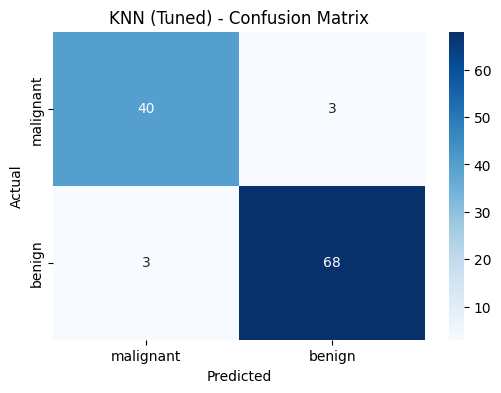

Model: SVM
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



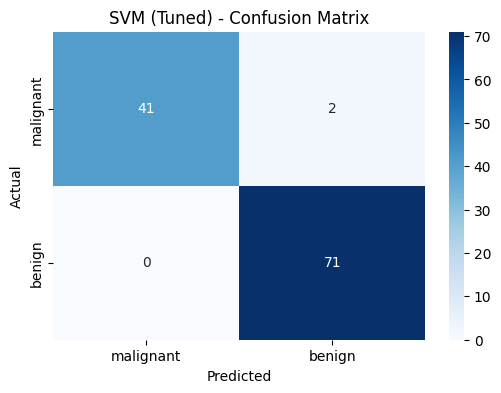

Model: Decision Tree
Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.91      0.92        43
      benign       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



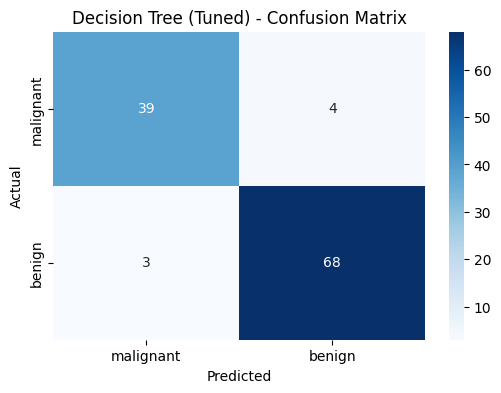

Model: Random Forest
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



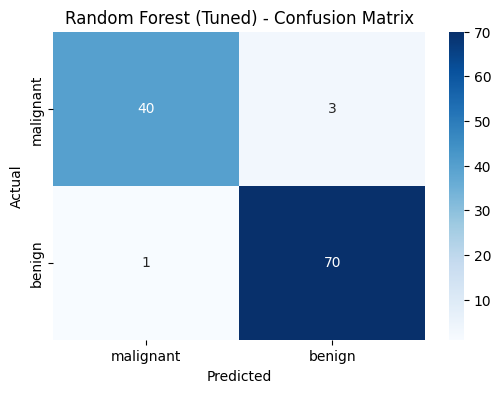

In [12]:
for name, config in best_models_p2.items():
    model = config['model']
    X_te = X_test_scaled if config['scaled'] else X_test

    y_pred = model.predict(X_te)

    print(f"{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=data.target_names)}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=data.target_names,
                yticklabels=data.target_names)
    plt.title(f'{name} (Tuned) - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


Task 2.13 – Identify best overall model and justify your choice using metrics

Best Overall Model: SVM (Tuned)

Test Set Performance Summary

| Model         | Accuracy | Macro F1 | Malignant Recall | False Negatives |
|---------------|----------|----------|------------------|-----------------|
| KNN           | 94.74%   | 0.94     | 0.93             | 3               |
| **SVM**       | **98.25%** | **0.98** | **0.95**       | **2**           |
| Decision Tree | 93.86%   | 0.93     | 0.91             | 4               |
| Random Forest | 96.49%   | 0.96     | 0.93             | 3               |

---

Justification

**1. Highest Accuracy** — SVM scored 98.25%, outperforming every other model
by at least 1.76 percentage points.

**2. Fewest Missed Cancer Cases** — Only 2 false negatives (missed malignant cases)
vs. 3–4 for every other model. In a medical context this is the most important metric.

**3. Perfect Benign Recall** — 0 false positives. No healthy patient was misdiagnosed
as malignant, avoiding unnecessary follow-up procedures.

**4. Most Balanced Per-Class Performance** — Malignant F1 of 0.98, benign F1 of 0.99.
No other model comes close to this balance across both classes.

**5. Consistent Results** — CV accuracy (97.58%) and test accuracy (98.25%) are nearly
identical, confirming the model generalizes well and isn't just getting lucky on
this test split.

---

Why Not Random Forest?

Random Forest is the second-best at 96.49% and is a strong model, but it had
3 false negatives vs. SVM's 2, and trails by nearly 2% in overall accuracy.

---

Conclusion

The tuned SVM with `C=1` and `kernel=rbf`, trained on scaled data, is the best
overall model — highest accuracy, fewest missed cancer cases, and perfect benign
recall. For a medical classification task, it's the clear choice.
